In [2]:
import folium
import branca.colormap as cm
import geopandas as gpd
from pathlib import Path

# load risk segments
segments = gpd.read_file(Path("..") / "data" / "processed" / "segments_risk.gpkg")

print(f"Loaded {len(segments)} segments")
print(f"Risk score range: {segments['risk_score'].min():.3f} – {segments['risk_score'].max():.3f}")


Loaded 3554 segments
Risk score range: 0.279 – 0.674


In [3]:
# center map on Tampere
map_center = [61.5, 23.8]
m = folium.Map(location=map_center, zoom_start=10, tiles="CartoDB positron")

# colormap: green (low risk) → yellow → red (high risk)
colormap = cm.LinearColormap(
    colors=["green", "yellow", "red"],
    vmin=segments["risk_score"].min(),
    vmax=segments["risk_score"].max(),
    caption="Vegetation Risk Score"
)

# add each segment colored by risk score
for _, row in segments.iterrows():
    folium.GeoJson(
        row["geometry"].__geo_interface__,
        style_function=lambda feat, score=row["risk_score"]: {
            "color": colormap(score),
            "weight": 3,
            "opacity": 0.8,
        }
    ).add_to(m)

colormap.add_to(m)

# save to file
output_path = Path("..") / "data" / "processed" / "risk_map.html"
m.save(output_path)
print(f"Saved map to {output_path}")


Saved map to ../data/processed/risk_map.html


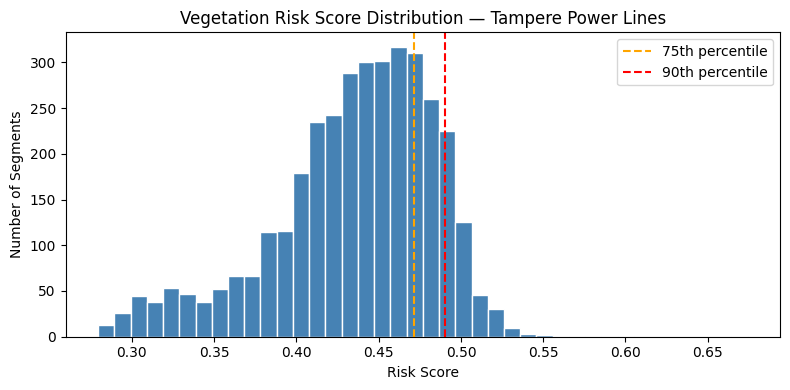

Saved risk_distribution.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(segments["risk_score"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(segments["risk_score"].quantile(0.75), color="orange", linestyle="--", label="75th percentile")
ax.axvline(segments["risk_score"].quantile(0.90), color="red", linestyle="--", label="90th percentile")

ax.set_xlabel("Risk Score")
ax.set_ylabel("Number of Segments")
ax.set_title("Vegetation Risk Score Distribution — Tampere Power Lines")
ax.legend()

plt.tight_layout()
plt.savefig(Path("..") / "data" / "processed" / "risk_distribution.png", dpi=150)
plt.show()
print("Saved risk_distribution.png")
